# Ground-state molecular energies with quantum phase estimation

This tutorial uses [quantum phase estimation](https://en.wikipedia.org/wiki/Quantum_phase_estimation_algorithm) (QPE) and the [Quantum Development Kit Chemistry library](https://github.com/microsoft/qdk-chemistry), called QDK/Chemistry in this documentation, to estimate the ground-state electronic energy of a stretched nitrogen molecule, N<sub>2</sub>.
It is intended for advanced undergraduate and early-stage graduate students who have introductory knowledge of quantum computing and chemistry.
*Before you begin* describes the prerequisites, software environment, and cumulative lab notebook assignment.

![Six-stage workflow. Define the energy target and matching classical reference; describe stretched nitrogen and select its correlated active space; map that model to qubits and prepare a trial state; estimate the active energy with IQPE; then add the core energy and compare the reconstructed total with the matching CASCI reference.](attachment:tutorial_qpe_workflow.png)

*The tutorial builds a compact classical molecular model, maps it to qubits, estimates the energy with IQPE, and checks the reconstructed total against the matching CASCI reference.*
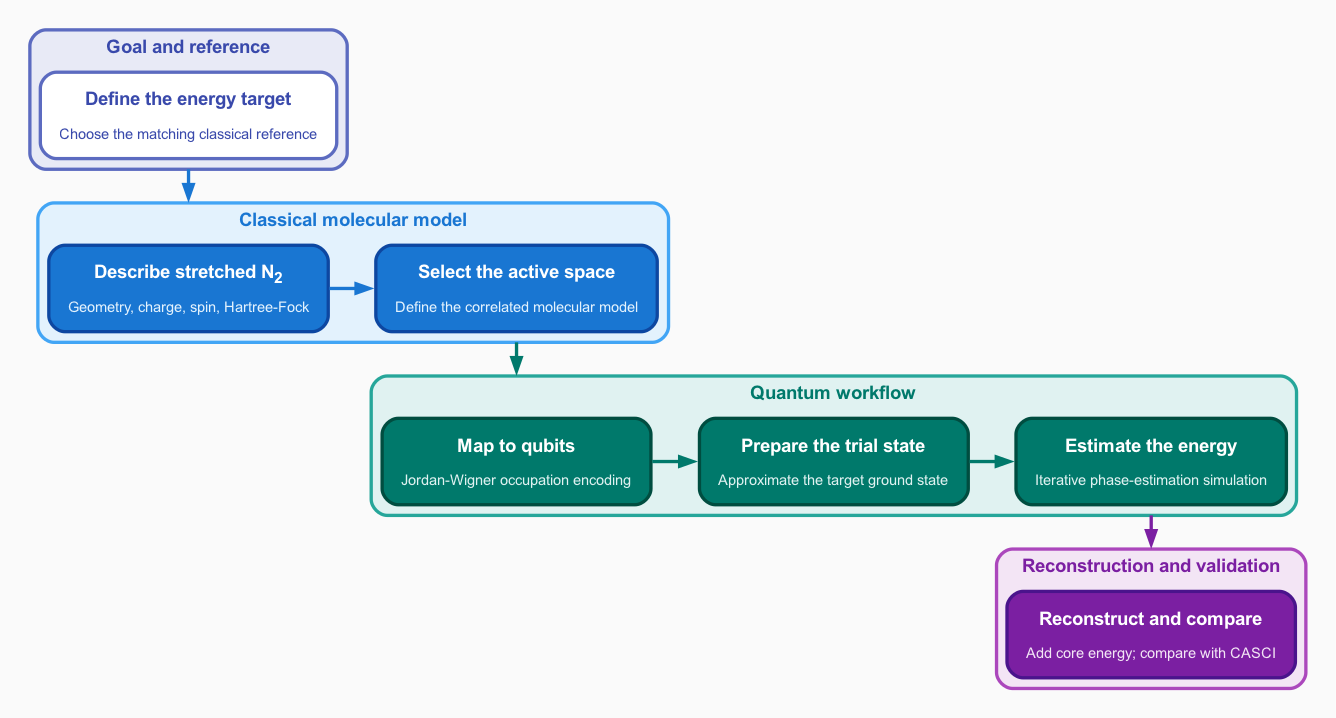

## Quantum chemistry background

[Electronic structure theory](https://en.wikipedia.org/wiki/Quantum_chemistry#Electronic_structure) applies quantum mechanics to the electrons in atoms and molecules.
For a system whose Hamiltonian does not depend explicitly on time, its stationary electronic states satisfy the [time-independent Schrödinger equation](https://en.wikipedia.org/wiki/Schr%C3%B6dinger_equation#Time-independent_equation):

$$
\hat{H} \vert\Psi\rangle = E \vert\Psi\rangle.
$$

Here, $\vert\Psi\rangle$ is the [wavefunction](https://en.wikipedia.org/wiki/Wave_function) of a stationary electronic state, and $E$ is its energy.
The possible solutions include the ground state, which has the lowest energy, and excited states with higher energies.
This tutorial seeks an approximate solution for the ground-state energy of stretched N<sub>2</sub>.

This tutorial uses the [Born–Oppenheimer approximation](https://en.wikipedia.org/wiki/Born%E2%80%93Oppenheimer_approximation), which holds the nuclei at fixed positions while solving for the electronic structure.
At a chosen molecular geometry, the electronic Hamiltonian includes the electron kinetic energy, electron–nucleus attraction, and electron–electron repulsion.
The repulsion among the fixed nuclei contributes separately to the total energy.
*Mapping the problem to qubits* develops the selected active-space form of this Hamiltonian and explains how it is mapped to qubits.
*Energy and accuracy* defines the target energy and the different error comparisons used in the tutorial.
*Describing the molecule* then specifies the molecular geometry and compares the initial fixed-geometry Hartree–Fock total energies from two related basis sets.

One useful representation starts with molecular orbitals, which describe the spatial part of one-electron states across the molecule.
In the spin basis used in this tutorial, the two possible [spin projections](<https://en.wikipedia.org/wiki/Spin_(physics)#Spin_projection_quantum_number_and_multiplicity>) are labeled $\alpha$ and $\beta$.
A spin orbital combines one spatial molecular orbital with either the $\alpha$ or $\beta$ spin function.
Each spin orbital can be occupied by at most one electron.
Each spatial orbital therefore corresponds to two spin orbitals and can accommodate at most two electrons, one with each spin projection.
An [electron configuration](https://en.wikipedia.org/wiki/Electron_configuration) specifies which spin orbitals are occupied.
A [Slater determinant](https://en.wikipedia.org/wiki/Slater_determinant) constructs a valid many-electron wavefunction for one configuration and enforces the [Pauli exclusion principle](https://en.wikipedia.org/wiki/Pauli_exclusion_principle).
Electron–electron interactions can couple different electron configurations, so a molecular state can require a combination of many Slater determinants.
The [Hartree–Fock method](https://en.wikipedia.org/wiki/Hartree%E2%80%93Fock_method) retains one optimized determinant as a tractable starting approximation, whereas active-space methods retain multiple determinants while restricting which orbital occupations can vary.
The *wavefunction hierarchy in Describing the molecule* summarizes how basis functions, orbitals, determinants, and many-electron wavefunctions relate.

When several configurations contribute substantially, the ground-state wavefunction combines their Slater determinants.
A coefficient for each determinant specifies its contribution to the wavefunction.
This need for several important configurations is called [static correlation](https://en.wikipedia.org/wiki/Electronic_correlation), and the resulting wavefunction is called multi-configurational.
The number of possible configurations grows rapidly with the number of electrons and orbitals.
An [active space](https://en.wikipedia.org/wiki/Complete_active_space) specifies a set of orbitals and a number of electrons whose distribution among those orbitals can vary across determinants in the multi-configurational wavefunction.
The remaining orbital occupations are fixed, and their energy contributions are tracked separately.
The active space therefore controls a central tradeoff in this tutorial: a larger space can describe more correlation, but it also produces a larger calculation and eventually requires more qubits.
*Choosing the active space* develops the correlated molecular model and selects the determinants that can contribute to its wavefunction.

## Why quantum computing?

The difficulty of a correlated calculation is not only the cost of evaluating one determinant.
The calculation must represent and combine many possible determinants.
For $N$ active electrons distributed among $M$ active spin orbitals, the determinant basis contains

$$
N_{\mathrm{det}} = \binom{M}{N}
$$

states before applying additional spin or molecular symmetries.
Fixing separate $\alpha$ and $\beta$ electron counts reduces this dimension to the sector-specific count derived in *Choosing the active space*, but does not remove the exponential growth.
At a fixed ratio of electrons to orbitals, this number grows exponentially with $M$.
[Full configuration interaction](https://en.wikipedia.org/wiki/Full_configuration_interaction) combines all allowed determinants in a chosen orbital space and therefore becomes impractical as that orbital space grows.
Approximate classical methods can reach larger spaces by retaining or compressing selected information, but their accuracy depends on preserving the correlations that matter.
When many configurations contribute substantially, omitted correlations can cause significant errors in the calculated energy.

The determinant count $N_{\mathrm{det}}$ is also the number of coefficients needed to store a general full configuration-interaction wavefunction explicitly on a classical computer.
An occupation-number encoding assigns one qubit to each spin orbital to record whether that orbital is unoccupied or occupied.
Once prepared, the qubit register carries amplitudes for a superposition of these $N_{\mathrm{det}}$ occupation patterns.
Entanglement links occupations across spin orbitals, so the joint quantum state represents configuration mixing without an explicit classical coefficient vector.
Preparing that state may still require classically supplied amplitudes and substantial resources.

A quantum register is a group of qubits treated as one part of a computation because they serve the same role.
The occupation-encoding qubits form the compute register, which stores the encoded fermionic state and is acted on by the qubit Hamiltonian.
[Ancilla qubits](https://en.wikipedia.org/wiki/Ancilla_bit) are additional qubits used for tasks such as control, temporary workspace, or readout; they do not represent additional spin orbitals and are counted separately.
*Mapping the problem to qubits* maps the selected electronic Hamiltonian to a qubit Hamiltonian and determines the size of this register.
During Hamiltonian time evolution, each energy eigenstate acquires a phase determined by its energy.
QPE estimates this phase and converts it to an energy eigenvalue.
This representation does not make the calculation automatically efficient.
Preparing a useful state, implementing time evolution, correcting errors, and repeating measurements can all require substantial resources.

Before running QPE, a state-preparation circuit loads an approximate wavefunction, called the trial state, onto the quantum register.
The trial state can be expressed as a combination of the eigenstates of the qubit Hamiltonian.
QPE can return the energy of any eigenstate represented in that combination; it does not independently find or prepare the ground state.

Let $\vert\Psi_0\rangle$ denote the exact ground state of the active-space Hamiltonian and $\vert\Psi_{\mathrm{trial}}\rangle$ denote the prepared trial state.
Their squared overlap is the ground-state fidelity

$$
F = \left\vert \langle\Psi_0 \vert \Psi_{\mathrm{trial}}\rangle \right\vert^2.
$$

Fidelity measures the weight of the ground state in the trial state.
In an ideal coherent phase-estimation measurement that uses one prepared system state to produce one complete phase result, $F$ is the probability of sampling the ground-state eigenphase.
The iterative implementation used by this tutorial instead prepares a new system state for each circuit that estimates one bit of the phase, so fidelity influences its bit statistics but does not by itself determine a complete-run success probability or trial count.
For this classically tractable teaching example, the classical active-space calculation supplies the important determinants and coefficients used to construct the trial state and later validate the quantum result.
*Preparing the trial state* develops overlap and fidelity, and *Iterative quantum phase estimation* explains how the energy is measured.

## Why stretched nitrogen?

In [molecular orbital theory](https://en.wikipedia.org/wiki/Molecular_orbital_theory), occupying a bonding orbital stabilizes a bond, whereas occupying the corresponding antibonding orbital opposes that stabilization.
Near the [equilibrium bond length](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7727379&Mask=1000) of $1.097685\ \text{Å}$ for N<sub>2</sub>, moving electrons from bonding to antibonding orbitals is energetically unfavorable, so one electron configuration dominates the ground-state wavefunction.
Bond stretching can make configurations with different occupations of the bonding and antibonding orbitals comparable in importance, increasing the multiconfigurational character of the ground state.
The selected stretched N<sub>2</sub> geometry is chosen to make this effect visible.
Later chapters quantify it through orbital entropies and determinant weights.

## Tutorial scope and structure

The tutorial deliberately selects a compact active-space model that can be solved exactly on a classical computer, allowing each quantum stage to be checked against a classical reference.
The circuits are executed on a classical simulator to validate the workflow.
Complete active space configuration interaction (CASCI) performs full configuration interaction within the selected active space rather than across all orbitals in the molecular model.
The final quantum calculation is compared with the CASCI energy of the same selected active-space Hamiltonian.
The tutorial uses one [millihartree](https://en.wikipedia.org/wiki/Hartree) ($1\ \mathrm{m}E_{\mathrm{h}}$) as a teaching target for this algorithmic comparison; however, meeting that target does not establish agreement with experiment or remove basis-set and active-space errors.

Each required chapter:

- introduces one stage of the calculation;
- provides a testable Python example where appropriate; and
- ends with questions and a lab notebook assignment.

The required chapters follow the stages in the *workflow diagram*:

- *Define the target energy and accuracy comparison*.
- *Construct the molecular system and Hartree–Fock starting wavefunction*.
- *Select a correlated active-space model*.
- *Map the active-space Hamiltonian to qubits*.
- *Prepare a trial state*.
- *Estimate the energy with IQPE and compare it with the matching classical reference*.

The final circuit simulation is the only intentionally long required example and reports progress after each complete run.

## Cumulative assignment

Download `the blank Markdown lab notebook` and maintain a working copy throughout the tutorial.
This is a note-taking document, not a Jupyter notebook.
The *lab notebook setup and field guide* explains how to use it.
Each required chapter asks you to record the inputs, decisions, results, and interpretations needed to reproduce the final calculation.
The lab notebook turns the chapter learning objectives into evidence that you can inspect and explain.
At the end, use the completed lab notebook to explain the final energy estimate and the limitations that remain.

00_before_you_begin
lab_notebook
01_energy_and_accuracy
02_describing_the_molecule
03_choosing_the_active_space
04_putting_the_problem_on_qubits
05_preparing_the_trial_state
06_iterative_phase_estimation